### Main goal of this notebook - Dataset contains mixed od pre-disaster and post-disaster images in single folder and labels for the post-disaster images in separate folder in json format. So we have to first Separate pre and post images, then we will masked the files (json--->mask)

### Imports

In [1]:
import os
import re
import json
import shutil
import numpy as np
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from pathlib import Path
from tqdm import tqdm
from shapely import wkt as shapely_wkt

### Paths / Roots

In [2]:
DATASET_ROOT = r"dataset/train"          # ← change if needed
IMAGES_DIR   = os.path.join(DATASET_ROOT, "images")
LABELS_DIR   = os.path.join(DATASET_ROOT, "labels")

PROCESSED_DIR = "processed"
PRE_DIR   = os.path.join(PROCESSED_DIR, "pre")
POST_DIR  = os.path.join(PROCESSED_DIR, "post")
MASK_DIR  = os.path.join(PROCESSED_DIR, "masks")

for d in [PRE_DIR, POST_DIR, MASK_DIR]:
    os.makedirs(d, exist_ok=True)

print("Successfully Done !")
print(f"  Images : {IMAGES_DIR}")
print(f"  Labels : {LABELS_DIR}")

Successfully Done !
  Images : dataset/train\images
  Labels : dataset/train\labels


In [3]:
all_images = sorted(os.listdir(IMAGES_DIR))
all_labels = sorted(os.listdir(LABELS_DIR))

print(f"Total images : {len(all_images)}")
print(f"Total labels : {len(all_labels)}")
print("\nSample names:")
for f in all_images[:6]:
    print(" ", f)

Total images : 5598
Total labels : 5598

Sample names:
  guatemala-volcano_00000000_post_disaster.png
  guatemala-volcano_00000000_pre_disaster.png
  guatemala-volcano_00000001_post_disaster.png
  guatemala-volcano_00000001_pre_disaster.png
  guatemala-volcano_00000002_post_disaster.png
  guatemala-volcano_00000002_pre_disaster.png


### pre and post images separation

In [4]:
pre_count = post_count = 0

for fname in tqdm(all_images, desc="Separating images"):
    src = os.path.join(IMAGES_DIR, fname)
    if "_pre_disaster" in fname:
        shutil.copy(src, os.path.join(PRE_DIR, fname))
        pre_count += 1
    elif "_post_disaster" in fname:
        shutil.copy(src, os.path.join(POST_DIR, fname))
        post_count += 1

print(f"\nPre-disaster  images: {pre_count}")
print(f"Post-disaster images: {post_count}")

Separating images: 100%|██████████████████████████████████████████████████████████| 5598/5598 [00:22<00:00, 248.34it/s]


Pre-disaster  images: 2799
Post-disaster images: 2799


### Sample label structures (.json format)

In [5]:
post_labels = [f for f in all_labels if "_post_disaster" in f]
sample_json_path = os.path.join(LABELS_DIR, post_labels[0])

print("Checking:", sample_json_path)

with open(sample_json_path) as f:
    data = json.load(f)

features = data.get("features", {}).get("xy", [])
print(f"Total features (buildings): {len(features)}")
print("\nFirst 3 feature properties:")
for i, feat in enumerate(features[:3]):
    print(f"  Feature {i}: {feat.get('properties', {})}")

# Check coordinate space
if features:
    wkt_sample = features[0].get("wkt", "")
    nums = re.findall(r"[-\d.]+", wkt_sample)
    nums = [float(n) for n in nums[:10]]
    print(f"\nSample coordinates: {nums[:6]}")
    print("→ Values 0–1024 = pixel space (good, no reprojection needed)")
    print("→ Values like -90, 14 = geographic (needs reprojection)")

Checking: dataset/train\labels\guatemala-volcano_00000000_post_disaster.json
Total features (buildings): 10

First 3 feature properties:
  Feature 0: {'feature_type': 'building', 'subtype': 'no-damage', 'uid': '486b0813-ecd2-4b84-856c-9c0e42156953'}
  Feature 1: {'feature_type': 'building', 'subtype': 'no-damage', 'uid': '139cf2c8-ad52-4739-82b5-bb646b215e76'}
  Feature 2: {'feature_type': 'building', 'subtype': 'no-damage', 'uid': 'd43deb4a-529c-4df4-b666-26dd5b17e040'}

Sample coordinates: [532.1863714054954, 165.9824503000504, 548.6019827848852, 224.1613082732768, 446.2458177229872, 264.4761185678668]
→ Values 0–1024 = pixel space (good, no reprojection needed)
→ Values like -90, 14 = geographic (needs reprojection)


### Mapping classes

In [7]:
DAMAGE_CLASSES = {
    "no-damage"     : 1,
    "minor-damage"  : 2,
    "major-damage"  : 3,
    "destroyed"     : 4,
    "un-classified" : 0,
}

CLASS_COLORS = {
    0: (0,   0,   0  ),   #black
    1: (0,   200, 0  ),   #green
    2: (255, 230, 0  ),   #yellow
    3: (255, 140, 0  ),   #orange
    4: (220, 30,  30 ),   #red
}

CLASS_NAMES = ["Background", "No damage", "Minor damage", "Major damage", "Destroyed"]

In [8]:
def parse_wkt_polygon_fallback(wkt_string):
    """
    Parses POLYGON ((x y, x y, ...)) using only built-in re module.
    Used as fallback if shapely fails on a single feature.
    """
    match = re.search(r"POLYGON\s*\(\((.+?)\)\)", wkt_string, re.IGNORECASE)
    if not match:
        return None
    coords = []
    for pair in match.group(1).split(","):
        parts = pair.strip().split()
        if len(parts) >= 2:
            try:
                coords.append((int(float(parts[0])), int(float(parts[1]))))
            except ValueError:
                continue
    return coords if len(coords) >= 3 else None

print("Fallback WKT parser ready.")

Fallback WKT parser ready.


### Function for  .json--->masked conversion

In [9]:
def json_to_mask(json_path, image_size=(1024, 1024)):
    
    with open(json_path) as f:
        data = json.load(f)

    mask = Image.new("L", image_size, 0)   # grayscale, 0 = background
    draw = ImageDraw.Draw(mask)

    features = data.get("features", {}).get("xy", [])

    for feat in features:
        props    = feat.get("properties", {})
        subtype  = props.get("subtype", "un-classified")
        class_id = DAMAGE_CLASSES.get(subtype, 0)

        wkt = feat.get("wkt", "")
        if not wkt:
            continue

        coords = None

        # Primary: shapely
        try:
            polygon = shapely_wkt.loads(wkt)
            coords  = [(int(x), int(y)) for x, y in polygon.exterior.coords]
        except Exception:
            pass

        # Fallback: pure-Python parser
        if not coords:
            coords = parse_wkt_polygon_fallback(wkt)

        if coords and len(coords) >= 3:
            draw.polygon(coords, fill=class_id)

    return np.array(mask)

print("Masked Successfully!!!")

Masked Successfully!!!


### Testing on single sample

Unique values in test mask: [0 1]
Non-zero pixels           : 15680


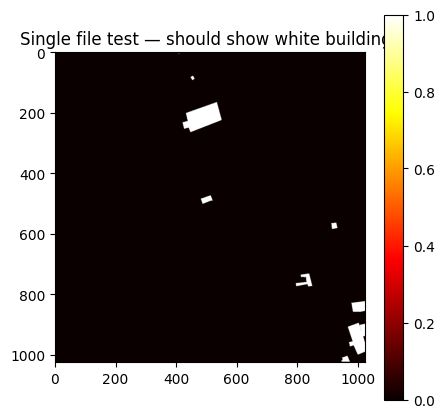

✓ Test passed — mask has non-zero pixels. Safe to generate all masks.


In [10]:
test_mask = json_to_mask(sample_json_path)

print("Unique values in test mask:", np.unique(test_mask))
print("Non-zero pixels           :", (test_mask > 0).sum())

plt.figure(figsize=(5, 5))
plt.imshow(test_mask, cmap="hot")
plt.title("Single file test — should show white buildings")
plt.colorbar()
plt.show()

assert (test_mask > 0).sum() > 0, \
    "STOP: Mask is still all zeros. Debug json_to_mask() before continuing."
print("✓ Test passed — mask has non-zero pixels. Safe to generate all masks.")

### Generating all masked

In [11]:
print(f"Generating masks for {len(post_labels)} post-disaster images...")

skipped = 0
for label_file in tqdm(post_labels, desc="Making masks"):
    json_path = os.path.join(LABELS_DIR, label_file)
    mask_name = label_file.replace(".json", ".png")
    save_path = os.path.join(MASK_DIR, mask_name)

    if os.path.exists(save_path):
        continue  

    try:
        mask = json_to_mask(json_path)
        Image.fromarray(mask.astype(np.uint8)).save(save_path)
    except Exception as e:
        print(f"  Skipping {label_file}: {e}")
        skipped += 1

print(f"\nMasks generated successfully!")
print(f"Total masks : {len(os.listdir(MASK_DIR))}")
print(f"Skipped     : {skipped}")

Generating masks for 2799 post-disaster images...


Making masks: 100%|████████████████████████████████████████████████████████████████| 2799/2799 [00:50<00:00, 55.35it/s]


Masks generated successfully!
Total masks : 2799
Skipped     : 0


### Visualize sample prediction

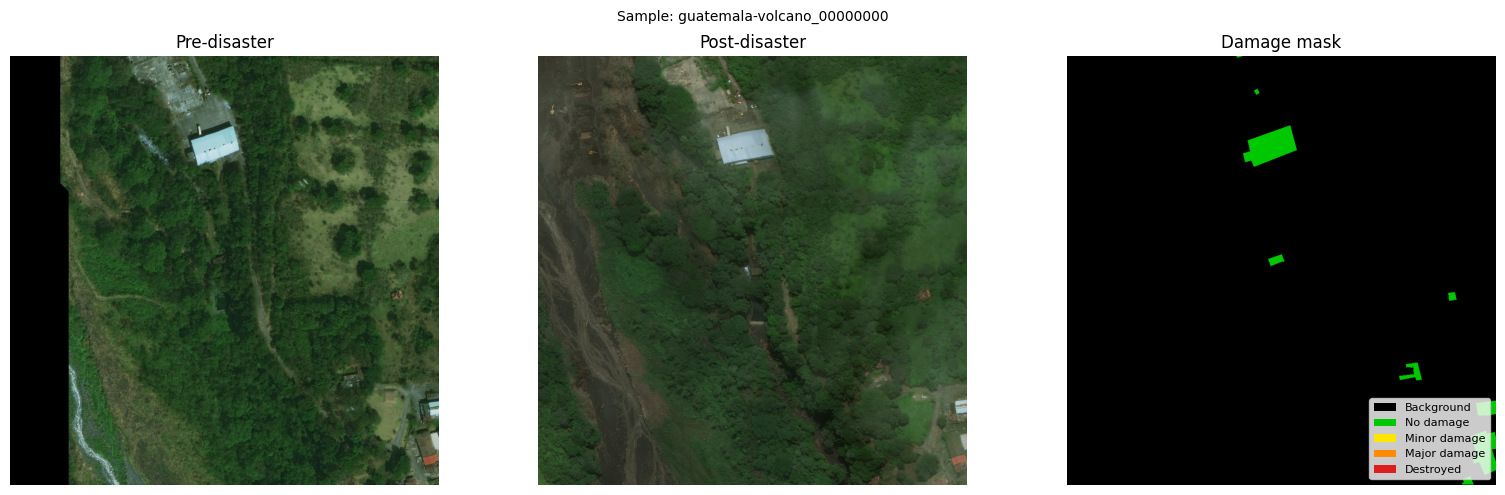


Class distribution in this mask:
  Class 0 (Background   ):  1032896 px  (98.5%)
  Class 1 (No damage    ):    15680 px  (1.5%)


In [13]:
def get_base_name(fname):
 
    return (fname
            .replace("_pre_disaster.png",  "")
            .replace("_post_disaster.png", "")
            .replace("_pre_disaster.json", "")
            .replace("_post_disaster.json",""))

sample_found = False
for pf in sorted(os.listdir(POST_DIR)):
    base      = get_base_name(pf)
    pre_name  = base + "_pre_disaster.png"
    mask_name = base + "_post_disaster.png"
    if (os.path.exists(os.path.join(PRE_DIR,  pre_name)) and
        os.path.exists(os.path.join(MASK_DIR, mask_name))):
        sample_found = True
        break

assert sample_found, "Could not find a complete pre/post/mask triplet."

pre_img  = Image.open(os.path.join(PRE_DIR,  pre_name)).convert("RGB")
post_img = Image.open(os.path.join(POST_DIR, pf)).convert("RGB")
mask_arr = np.array(Image.open(os.path.join(MASK_DIR, mask_name)))

color_mask = np.zeros((*mask_arr.shape, 3), dtype=np.uint8)
for cls, color in CLASS_COLORS.items():
    color_mask[mask_arr == cls] = color

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].imshow(pre_img);    axes[0].set_title("Pre-disaster");  axes[0].axis("off")
axes[1].imshow(post_img);   axes[1].set_title("Post-disaster"); axes[1].axis("off")
axes[2].imshow(color_mask); axes[2].set_title("Damage mask");   axes[2].axis("off")

legend_elements = [
    Patch(facecolor=tuple(c/255 for c in CLASS_COLORS[i]), label=CLASS_NAMES[i])
    for i in range(5)
]
axes[2].legend(handles=legend_elements, loc="lower right", fontsize=8, framealpha=0.8)

plt.suptitle(f"Sample: {base}", fontsize=10)
plt.tight_layout()
plt.savefig("sample_verification.png", dpi=150, bbox_inches="tight")
plt.show()

# Class distribution
unique, counts = np.unique(mask_arr, return_counts=True)
print("\nClass distribution in this mask:")
for u, c in zip(unique, counts):
    print(f"  Class {u} ({CLASS_NAMES[u]:13s}): {c:8d} px  ({100*c/mask_arr.size:.1f}%)")

### Build matched pairs list and save to pairs.json

In [14]:
pre_files  = set(os.listdir(PRE_DIR))
post_files = set(os.listdir(POST_DIR))
mask_files = set(os.listdir(MASK_DIR))

pairs = []
missing = 0
for pf in sorted(post_files):
    base      = get_base_name(pf)
    pre_name  = base + "_pre_disaster.png"
    mask_name = base + "_post_disaster.png"

    if pre_name in pre_files and mask_name in mask_files:
        pairs.append({
            "pre" : os.path.join(PRE_DIR,  pre_name),
            "post": os.path.join(POST_DIR, pf),
            "mask": os.path.join(MASK_DIR, mask_name),
        })
    else:
        missing += 1

print(f"Matched pairs : {len(pairs)}")
print(f"Missing       : {missing}")

with open("pairs.json", "w") as f:
    json.dump(pairs, f, indent=2)

print("\nSaved pairs.json ✓")

Matched pairs : 2799
Missing       : 0

Saved pairs.json ✓
